In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

## Print statistics

In [2]:
let_iso = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\LET_Isocentre.csv", skiprows=4)
print('LET : ' + str(round(let_iso['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0],2)) + ' MeV/mm/(g/cm3)')

dose_iso = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\Dose_Isocentre.csv", skiprows=4)
print('Dose: ' + str(dose_iso['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

let_cells = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\LET_CellLayer.csv", skiprows=4)
print('LET : ' + str(round(let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0],2)) + ' MeV/mm/(g/cm3)')

dose_cells = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\Dose_CellLayer.csv", skiprows=4)
print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

LET : 2.02 MeV/mm/(g/cm3)
Dose: 5.785960599524741e-10 Gy
LET : 32.23 MeV/mm/(g/cm3)
Dose: 9.352253416139431e-10 Gy


## Read in MONAS data

In [7]:
data = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\MKModel_SMKM.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SMKM = pd.concat([new, data])
print(SMKM)

   # Dose[Gy]   Survival   SurvivalStd       RBE   RBEStd
0         0.0   1.000000           0.0  1.000000      0.0
0         2.0   0.259412           0.0  1.815716      0.0
1         5.0   0.017094           0.0  1.463808      0.0
2         8.0   0.000493           0.0  1.323222      0.0


In [8]:
data = pd.read_csv(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONASTEST\MKModel_StaurationCorrected.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SatCorr = pd.concat([new, data])
print(SatCorr)

   # Dose[Gy]   Survival   SurvivalStd       RBE   RBEStd
0         0.0   1.000000           0.0  1.000000      0.0
0         2.0   0.254639           0.0  1.832453      0.0
1         5.0   0.015456           0.0  1.485534      0.0
2         8.0   0.000381           0.0  1.348783      0.0


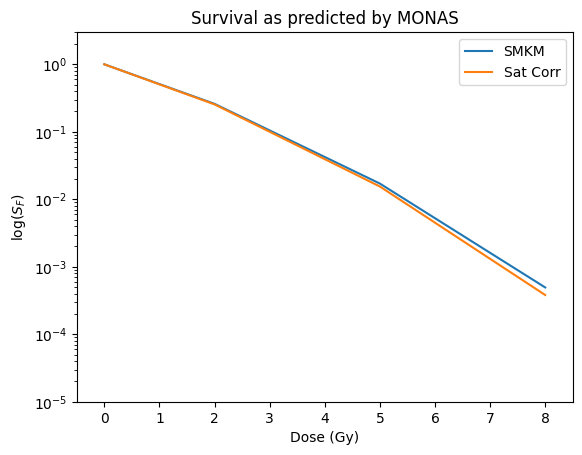

In [10]:
plt.title('Survival as predicted by MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.plot(SMKM['# Dose[Gy]'], SMKM[' Survival'], label = 'SMKM')
plt.plot(SatCorr['# Dose[Gy]'], SatCorr[' Survival'], label = 'Sat Corr')
plt.yscale('log')
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.legend()